In [12]:
# NumPy -> Numerical operations
import numpy as np

# Matplotlib -> Graph plotting
import matplotlib.pyplot as plt

# make_classification -> Generates synthetic dataset
from sklearn.datasets import make_classification

# train_test_split -> Splits dataset into training/testing
from sklearn.model_selection import train_test_split

# KNeighborsClassifier -> KNN Algorithm
from sklearn.neighbors import KNeighborsClassifier

# Metrics for model evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [13]:
# Create artificial classification dataset

X, y = make_classification(

    n_samples=300,          # Total data points

    n_features=2,           # Number of features

    n_informative=2,        # Useful features

    n_redundant=0,          # No redundant features

    n_clusters_per_class=1,

    class_sep=2,            # Separation between classes

    random_state=42
)

# Print dataset shape
print("Feature Shape :", X.shape)

# Print target shape
print("Target Shape :", y.shape)

Feature Shape : (300, 2)
Target Shape : (300,)


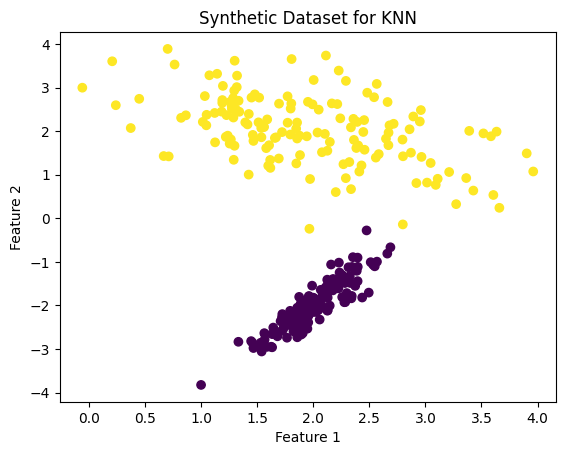

In [14]:
# Scatter plot of dataset

plt.scatter(

    X[:,0],     # Feature 1

    X[:,1],     # Feature 2

    c=y         # Color based on class labels
)

plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.title("Synthetic Dataset for KNN")

plt.show()


In [15]:
# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,      # 20% testing data

    random_state=42
)

# Print shapes
print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (240, 2)
Testing Shape : (60, 2)


In [16]:
# Create KNN classifier

knn = KNeighborsClassifier(

    n_neighbors=3     # Number of nearest neighbors
)

In [17]:
# Train model using training data

knn.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [18]:
# Predict output for test data

y_pred = knn.predict(X_test)

print("Predicted Values :")

print(y_pred)

Predicted Values :
[0 1 1 0 1 1 1 1 0 1 0 0 0 0 1 0 0 0 1 1 1 1 1 0 0 0 0 1 1 0 0 1 1 1 1 0 1
 0 1 0 0 1 1 0 1 0 0 1 0 0 1 1 1 0 1 1 0 1 1 0]


In [19]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

# Print confusion matrix
print("\nConfusion Matrix :")

print(confusion_matrix(y_test, y_pred))

# Print classification report
print("\nClassification Report :")

print(classification_report(y_test, y_pred))

Accuracy : 0.9833333333333333

Confusion Matrix :
[[28  1]
 [ 0 31]]

Classification Report :
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.97      1.00      0.98        31

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



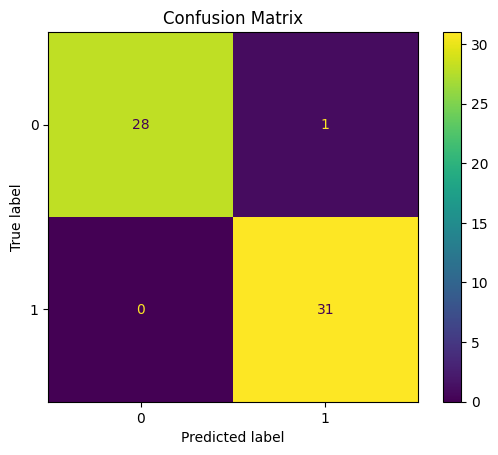

In [20]:
# Visualize confusion matrix

ConfusionMatrixDisplay.from_predictions(

    y_test,
    y_pred
)

plt.title("Confusion Matrix")

plt.show()

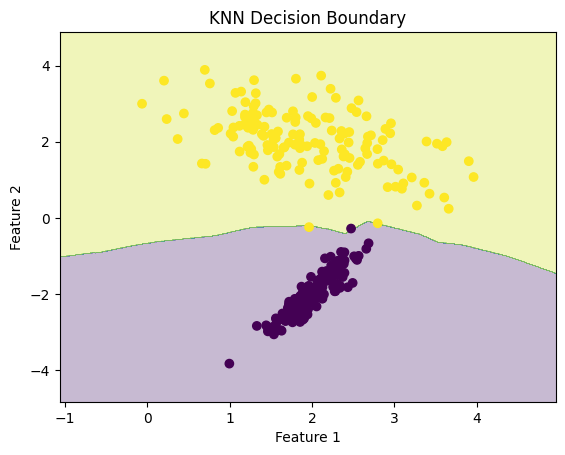

In [21]:
# Function to visualize decision regions

def plot_decision_boundary(X, y, model):

    # Define graph limits
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1

    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

    # Create mesh grid
    xx, yy = np.meshgrid(

        np.arange(x_min, x_max, 0.01),

        np.arange(y_min, y_max, 0.01)
    )

    # Predict all grid points
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Reshape predictions
    Z = Z.reshape(xx.shape)

    # Plot decision regions
    plt.contourf(xx, yy, Z, alpha=0.3)

    # Plot actual data points
    plt.scatter(

        X[:,0],
        X[:,1],
        c=y
    )

    plt.xlabel("Feature 1")

    plt.ylabel("Feature 2")

    plt.title("KNN Decision Boundary")

    plt.show()


# Call function
plot_decision_boundary(X, y, knn)

In [22]:
# New custom input data

new_data = [[1.5, -0.5]]

# Predict class
prediction = knn.predict(new_data)

print("Prediction for New Data :", prediction)

Prediction for New Data : [0]
